## Importación de librerias necesarias para el programa. 

    Difernetes módulos y Clases de sklearn. 
    Numpy
    Pandas
    ...

In [1]:
# ============================================
#  Importaciones y configuración inicial
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, roc_auc_score
)
import cv2


## Define tamaño de imagenes, cantidad de imagenes, la semilla y la configuración de las graficas.

In [2]:
# Parámetros generales
IMG_SIZE = 64          # Tamaño de las imágenes
N_SAMPLES = 2000       # Número de imágenes para muestra inicial
RANDOM_SEED = 42       # Semilla para reproducibilidad

# Ruta donde están las imágenes (ajusta si es diferente en tu notebook)
PATH_IMAGES = "images_training_rev1/"

# Configuración visual
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)
np.random.seed(RANDOM_SEED)

print("Librerías importadas y entorno configurado correctamente.")


Librerías importadas y entorno configurado correctamente.


## Carga dataset

In [3]:
# ============================================
# Cargar dataset y generar etiquetas
# ============================================

# Cargar el archivo CSV
df = pd.read_csv("training_solutions_rev1.csv")

## Imprimir información dataset

In [4]:
print("Información general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61578 entries, 0 to 61577
Data columns (total 38 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GalaxyID   61578 non-null  int64  
 1   Class1.1   61578 non-null  float64
 2   Class1.2   61578 non-null  float64
 3   Class1.3   61578 non-null  float64
 4   Class2.1   61578 non-null  float64
 5   Class2.2   61578 non-null  float64
 6   Class3.1   61578 non-null  float64
 7   Class3.2   61578 non-null  float64
 8   Class4.1   61578 non-null  float64
 9   Class4.2   61578 non-null  float64
 10  Class5.1   61578 non-null  float64
 11  Class5.2   61578 non-null  float64
 12  Class5.3   61578 non-null  float64
 13  Class5.4   61578 non-null  float64
 14  Class6.1   61578 non-null  float64
 15  Class6.2   61578 non-null  float64
 16  Class7.1   61578 non-null  float64
 17  Class7.2   61578 non-null  float64
 18  Class7.3   61578 non-null  float64
 19  Class8.1   61

## Cabecera del Dataset

In [5]:
print("Primeras filas:")
display(df.head())


Primeras filas:


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


## Clases Dominantes

In [6]:
df = pd.read_csv("training_solutions_rev1.csv")
# Crear columna con la clase dominante por fila
df["label"] = df.iloc[:, 1:].idxmax(axis=1)

# Mostrar las clases detectadas y su frecuencia
conteo_clases = df["label"].value_counts()

print("\n📊 Número de galaxias por clase:")
display(conteo_clases)




📊 Número de galaxias por clase:


label
Class6.2    36706
Class1.2    15940
Class1.1     5449
Class6.1     3470
Class1.3       13
Name: count, dtype: int64

## Gráfico de distribución de clases

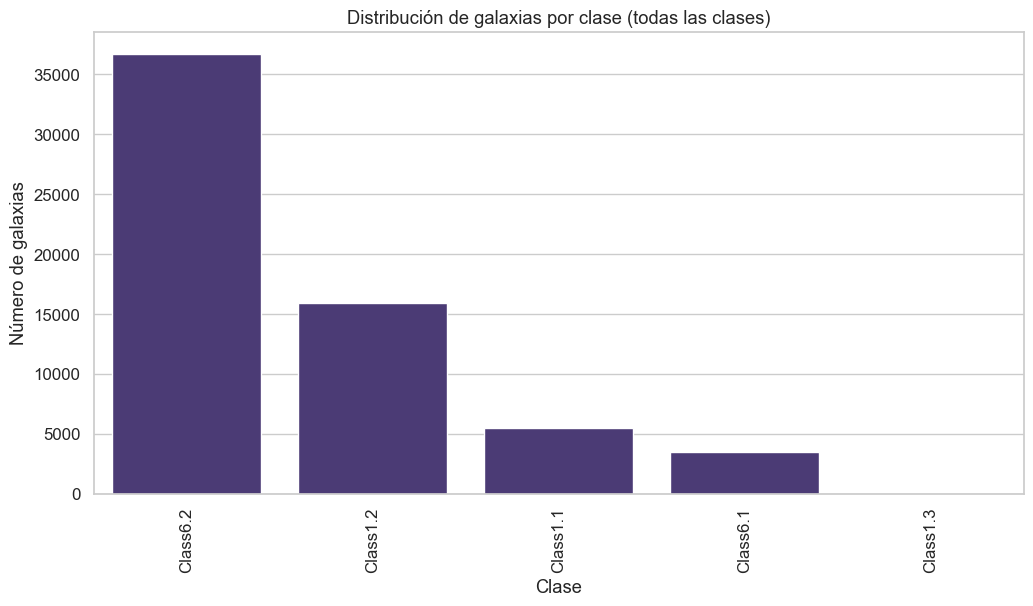

In [7]:
# Gráfico de distribución de clases
plt.figure(figsize=(12, 6))
sns.barplot(x=conteo_clases.index, y=conteo_clases.values)
plt.xticks(rotation=90)
plt.title("Distribución de galaxias por clase (todas las clases)")
plt.xlabel("Clase")
plt.ylabel("Número de galaxias")
plt.show()

## Distribución de las clases

🔝 Clases seleccionadas (Top 5):
['Class6.2', 'Class1.2', 'Class1.1', 'Class6.1', 'Class1.3']

📂 Imágenes disponibles para las 5 clases: 61578
🧮 Total de imágenes seleccionadas: 1613


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31596\59434674.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_SAMPLES // 5), random_state=RANDOM_SEED))


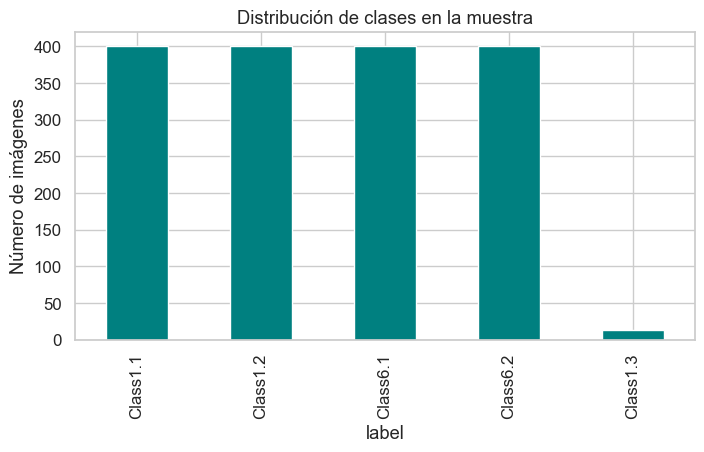

In [9]:
# ============================================
#   Selección de las 5 clases más frecuentes
#     y creación de muestra de 2000 imágenes
# ============================================

# Seleccionar las 5 clases con más galaxias
top5_classes = conteo_clases.nlargest(5).index
df_top5 = df[df["label"].isin(top5_classes)]

print(f"🔝 Clases seleccionadas (Top 5):\n{list(top5_classes)}")

# Verificar que existan las imágenes en la carpeta
df_top5["image_path"] = df_top5["GalaxyID"].apply(
    lambda x: os.path.join(PATH_IMAGES, f"{x}.jpg")
)
df_top5 = df_top5[df_top5["image_path"].apply(os.path.exists)]

print(f"\n📂 Imágenes disponibles para las 5 clases: {len(df_top5)}")

# Tomar muestra balanceada de 2000 imágenes
df_sample = (
    df_top5.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_SAMPLES // 5), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

print(f"🧮 Total de imágenes seleccionadas: {len(df_sample)}")

# Mostrar distribución final de la muestra
df_sample["label"].value_counts().plot(
    kind="bar", color="teal", figsize=(8, 4), title="Distribución de clases en la muestra"
)
plt.ylabel("Número de imágenes")
plt.show()


## Muestra de imágenes y procesamiento

📥 Cargando y procesando imágenes...


100%|█████████████████████████████████████████████████████████████████████████████| 1613/1613 [00:10<00:00, 159.53it/s]
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128301 (\N{TELESCOPE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)



✅ Imágenes cargadas correctamente: 1613 muestras, tamaño de vector = 4096
🔢 Clases codificadas: [np.str_('Class1.1'), np.str_('Class1.2'), np.str_('Class1.3'), np.str_('Class6.1'), np.str_('Class6.2')]


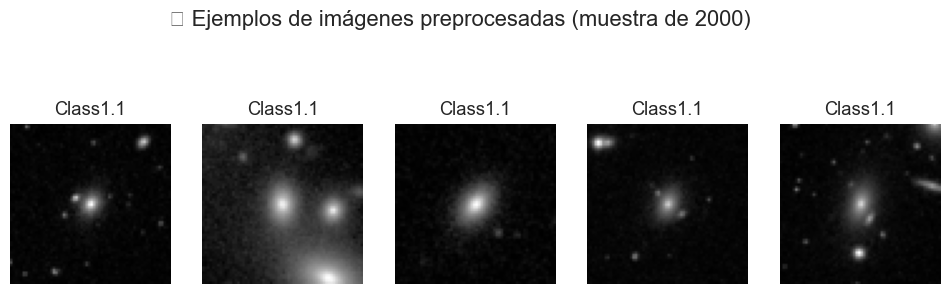

In [10]:
# ============================================
# Preprocesamiento de imágenes
# ============================================

def cargar_imagen(ruta, size=(IMG_SIZE, IMG_SIZE)):
    """Carga una imagen en escala de grises y la devuelve como array normalizado."""
    try:
        img = Image.open(ruta).convert('L')   # Escala de grises
        img = img.resize(size)
        return np.array(img) / 255.0          # Normalizar [0,1]
    except Exception as e:
        print(f"⚠️ Error al cargar {ruta}: {e}")
        return None

# Cargar todas las imágenes de la muestra
X, y = [], []
print("📥 Cargando y procesando imágenes...")

for _, fila in tqdm(df_sample.iterrows(), total=len(df_sample)):
    arr = cargar_imagen(fila["image_path"])
    if arr is not None:
        X.append(arr.flatten())  # Convertir imagen a vector 1D
        y.append(fila["label"])

X = np.array(X)
y = np.array(y)

print(f"\n✅ Imágenes cargadas correctamente: {X.shape[0]} muestras, tamaño de vector = {X.shape[1]}")

# Codificar etiquetas (string -> número)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"🔢 Clases codificadas: {list(le.classes_)}")

# Mostrar algunos ejemplos visuales
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img = X[i].reshape(IMG_SIZE, IMG_SIZE)
    plt.imshow(img, cmap='gray')
    plt.title(le.inverse_transform([y_encoded[i]])[0])
    plt.axis('off')
plt.suptitle("🔭 Ejemplos de imágenes preprocesadas (muestra de 2000)")
plt.show()


In [11]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, title="", cv=5, scoring="accuracy", n_jobs=-1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, 'o-', label="Entrenamiento")
    plt.plot(train_sizes, test_mean, 'o-', label="Validación")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
    plt.title(title)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Precisión")
    plt.legend()
    plt.grid(True)
    plt.show()


## División de los conjuntos de train/test

In [12]:
# ============================================
# División del conjunto y normalización
# ============================================

# División en entrenamiento y prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_SEED
)

print(f"🧩 Tamaños -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Escalamiento de características
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("✅ Datos escalados correctamente.")


🧩 Tamaños -> Train: 1290, Test: 323
✅ Datos escalados correctamente.


## Regresión Logística

In [13]:
# ============================================
# -A Regresión Logística
# ============================================

print("⚙️ Entrenando modelo: Regresión Logística...")

log_reg = LogisticRegression(
    max_iter=500,
    random_state=RANDOM_SEED,
    multi_class='ovr'
)
log_reg.fit(X_train_s, y_train)

# Predicciones
y_pred_lr = log_reg.predict(X_test_s)
y_prob_lr = log_reg.predict_proba(X_test_s)

# Reporte de clasificación
print("\n📊 Reporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


⚙️ Entrenando modelo: Regresión Logística...


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



📊 Reporte de Clasificación (Regresión Logística):
              precision    recall  f1-score   support

    Class1.1       0.25      0.23      0.24        80
    Class1.2       0.40      0.49      0.44        80
    Class1.3       0.33      0.33      0.33         3
    Class6.1       0.27      0.26      0.26        80
    Class6.2       0.32      0.29      0.30        80

    accuracy                           0.32       323
   macro avg       0.31      0.32      0.32       323
weighted avg       0.31      0.32      0.31       323



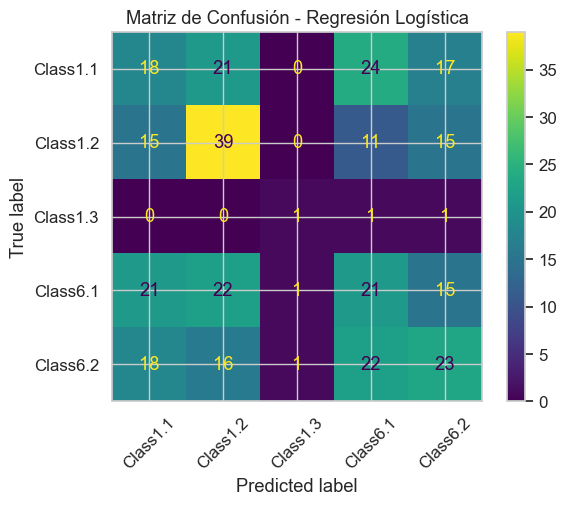

In [14]:
# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

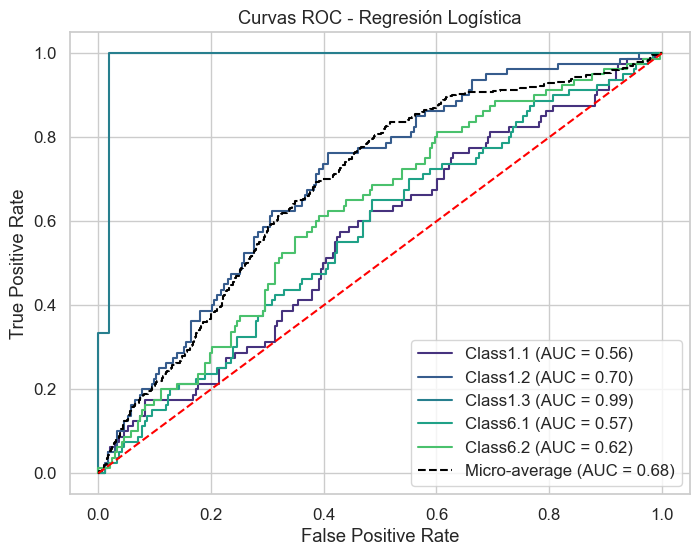

In [15]:
# === Curvas ROC ===
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Curvas micro y macro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_lr.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC
plt.figure(figsize=(8, 6))
for i, clase in enumerate(le.classes_):
    plt.plot(fpr[i], tpr[i], label=f'{clase} (AUC = {roc_auc[i]:.2f})')
plt.plot(fpr["micro"], tpr["micro"], 'k--', label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Regresión Logística")
plt.legend()
plt.show()


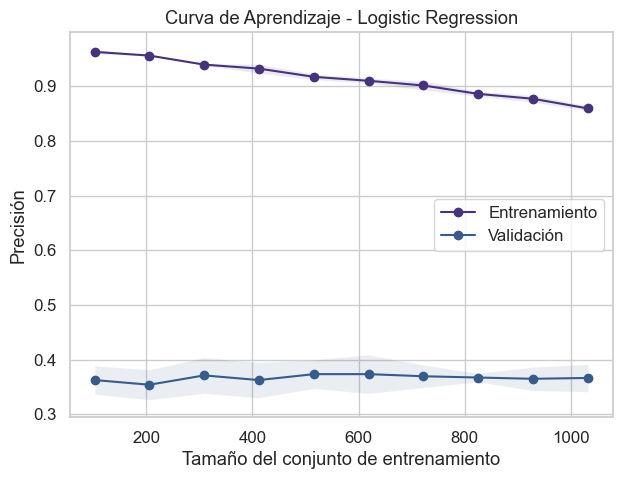

Precisión Entrenamiento: 0.488
Precisión Validación/Test: 0.294


In [16]:
# Curvas de aprendizaje - Logistic Regression
plot_learning_curve(log_reg, X_train, y_train, title="Curva de Aprendizaje - Logistic Regression")

# Curva de desempeño entrenamiento vs prueba
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


## Support Vector Machine

In [17]:
# ============================================
# 6-B SVM (kernel RBF)
# ============================================

print("⚙️ Entrenando modelo: SVM (RBF)...")

svm_clf = SVC(
    kernel='rbf',
    probability=True,
    random_state=RANDOM_SEED
)
svm_clf.fit(X_train_s, y_train)

# Predicciones
y_pred_svm = svm_clf.predict(X_test_s)
y_prob_svm = svm_clf.predict_proba(X_test_s)

print("\n📊 Reporte de Clasificación (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


⚙️ Entrenando modelo: SVM (RBF)...

📊 Reporte de Clasificación (SVM):
              precision    recall  f1-score   support

    Class1.1       0.34      0.30      0.32        80
    Class1.2       0.37      0.61      0.46        80
    Class1.3       0.00      0.00      0.00         3
    Class6.1       0.37      0.36      0.37        80
    Class6.2       0.32      0.16      0.21        80

    accuracy                           0.36       323
   macro avg       0.28      0.29      0.27       323
weighted avg       0.35      0.36      0.34       323



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

## Matriz de confusión

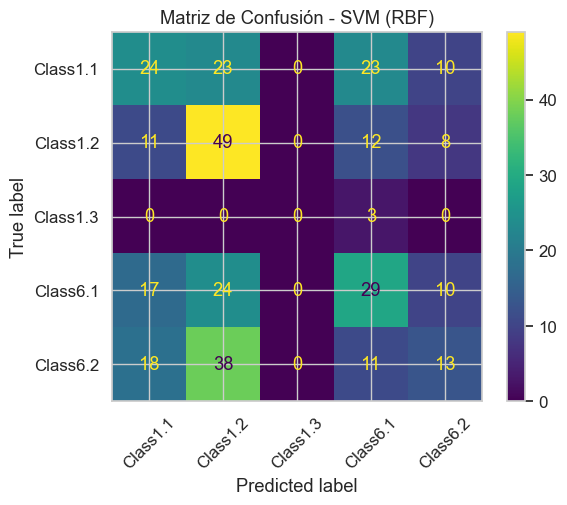

In [18]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp_svm.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - SVM (RBF)")
plt.show()

## Curva ROC

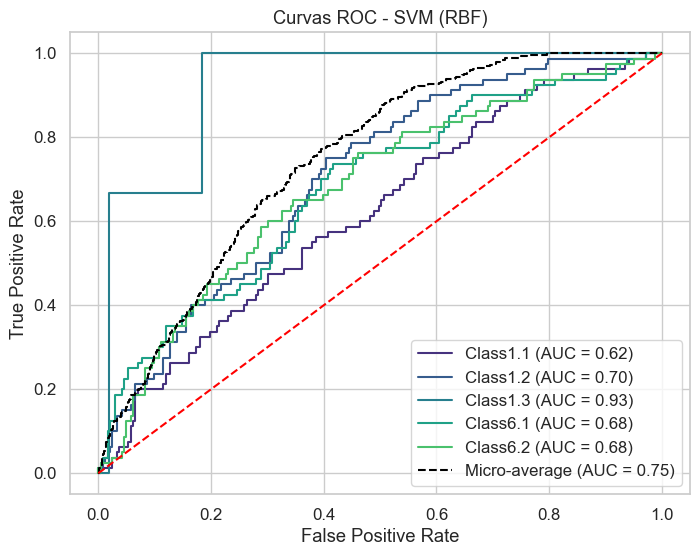

In [19]:
# === Curvas ROC ===
fpr_svm, tpr_svm, roc_auc_svm = {}, {}, {}
for i in range(n_classes):
    fpr_svm[i], tpr_svm[i], _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])

fpr_svm["micro"], tpr_svm["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_svm.ravel())
roc_auc_svm["micro"] = auc(fpr_svm["micro"], tpr_svm["micro"])

# Plot ROC
plt.figure(figsize=(8, 6))
for i, clase in enumerate(le.classes_):
    plt.plot(fpr_svm[i], tpr_svm[i], label=f'{clase} (AUC = {roc_auc_svm[i]:.2f})')
plt.plot(fpr_svm["micro"], tpr_svm["micro"], 'k--', label=f'Micro-average (AUC = {roc_auc_svm["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - SVM (RBF)")
plt.legend()
plt.show()

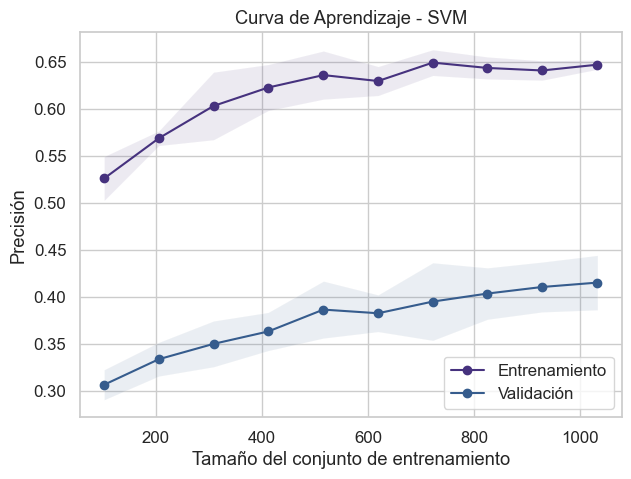

Precisión Entrenamiento: 0.262
Precisión Validación/Test: 0.254


In [20]:
# Curvas de aprendizaje - SVM
plot_learning_curve(svm_clf, X_train, y_train, title="Curva de Aprendizaje - SVM")

# Curva de desempeño entrenamiento vs prueba
train_score = svm_clf.score(X_train, y_train)
test_score = svm_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


## Árbol de Decisión

In [21]:
# ============================================
# 6️⃣-C Árbol de Decisión
# ============================================

print("Entrenando modelo: Árbol de Decisión...")

tree_clf = DecisionTreeClassifier(random_state=RANDOM_SEED)
tree_clf.fit(X_train_s, y_train)

# Predicciones
y_pred_tree = tree_clf.predict(X_test_s)
y_prob_tree = tree_clf.predict_proba(X_test_s)

print("\n📊 Reporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))

Entrenando modelo: Árbol de Decisión...

📊 Reporte de Clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

    Class1.1       0.33      0.34      0.33        80
    Class1.2       0.32      0.38      0.34        80
    Class1.3       0.00      0.00      0.00         3
    Class6.1       0.33      0.31      0.32        80
    Class6.2       0.26      0.23      0.24        80

    accuracy                           0.31       323
   macro avg       0.25      0.25      0.25       323
weighted avg       0.31      0.31      0.31       323



## Matriz de confusión

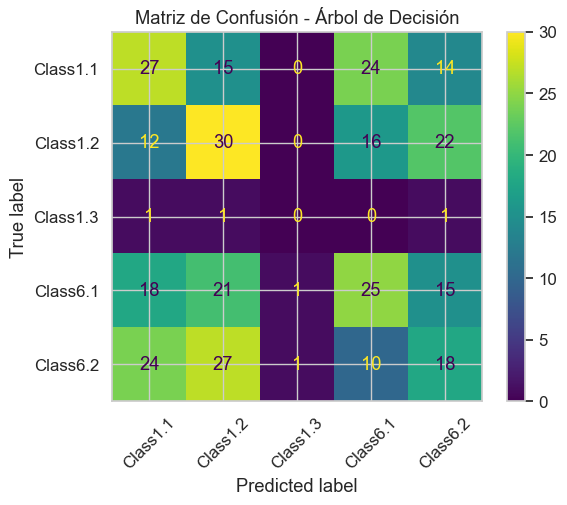

In [22]:
# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=le.classes_)
disp_tree.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

## Curva ROC

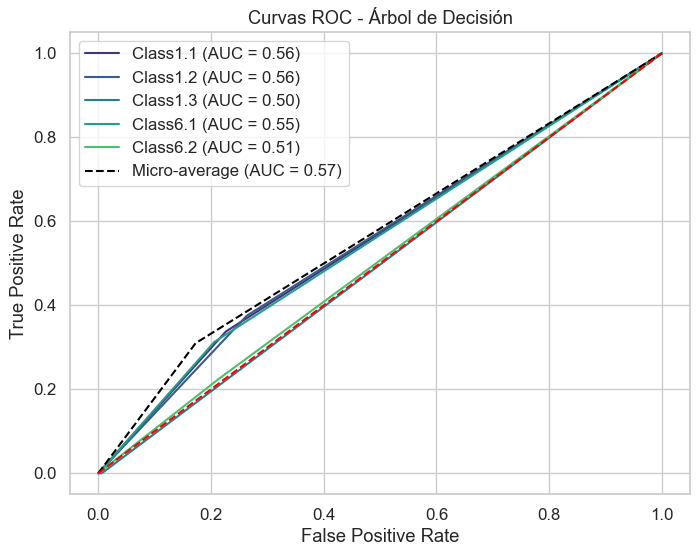

In [24]:
# === Curvas ROC ===
fpr_tree, tpr_tree, roc_auc_tree = {}, {}, {}
for i in range(n_classes):
    fpr_tree[i], tpr_tree[i], _ = roc_curve(y_test_bin[:, i], y_prob_tree[:, i])
    roc_auc_tree[i] = auc(fpr_tree[i], tpr_tree[i])

fpr_tree["micro"], tpr_tree["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_tree.ravel())
roc_auc_tree["micro"] = auc(fpr_tree["micro"], tpr_tree["micro"])

# Plot ROC
plt.figure(figsize=(8, 6))
for i, clase in enumerate(le.classes_):
    plt.plot(fpr_tree[i], tpr_tree[i], label=f'{clase} (AUC = {roc_auc_tree[i]:.2f})')
plt.plot(fpr_tree["micro"], tpr_tree["micro"], 'k--', label=f'Micro-average (AUC = {roc_auc_tree["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Árbol de Decisión")
plt.legend()
plt.show()

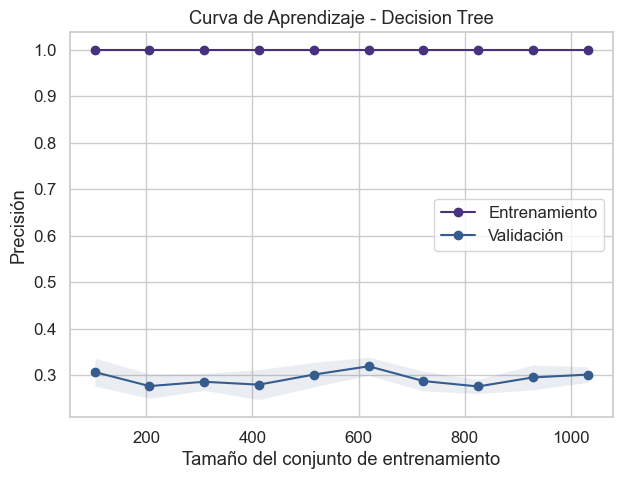

Precisión Entrenamiento: 0.248
Precisión Validación/Test: 0.248


In [25]:
# Curvas de aprendizaje - Decision Tree
plot_learning_curve(tree_clf, X_train, y_train, title="Curva de Aprendizaje - Decision Tree")

# Curva de desempeño entrenamiento vs prueba
train_score = tree_clf.score(X_train, y_train)
test_score = tree_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


## Comparación de modelos

In [26]:
# ============================================
# 7️⃣ Comparación de resultados entre modelos
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas para cada modelo
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM (RBF)', 'Árbol de Decisión'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='macro'),
        precision_score(y_test, y_pred_svm, average='macro'),
        precision_score(y_test, y_pred_tree, average='macro')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='macro'),
        recall_score(y_test, y_pred_svm, average='macro'),
        recall_score(y_test, y_pred_tree, average='macro')
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro')
    ]
})


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Comparación por medio de Gráficas

📈 Resultados comparativos (muestra de 2000 imágenes):


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.3158,0.3142,0.3192,0.3154
1,SVM (RBF),0.3560,0.2795,0.2875,0.2720
2,Árbol de Decisión,0.3096,0.2478,0.2500,0.2481


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31596\1408102535.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


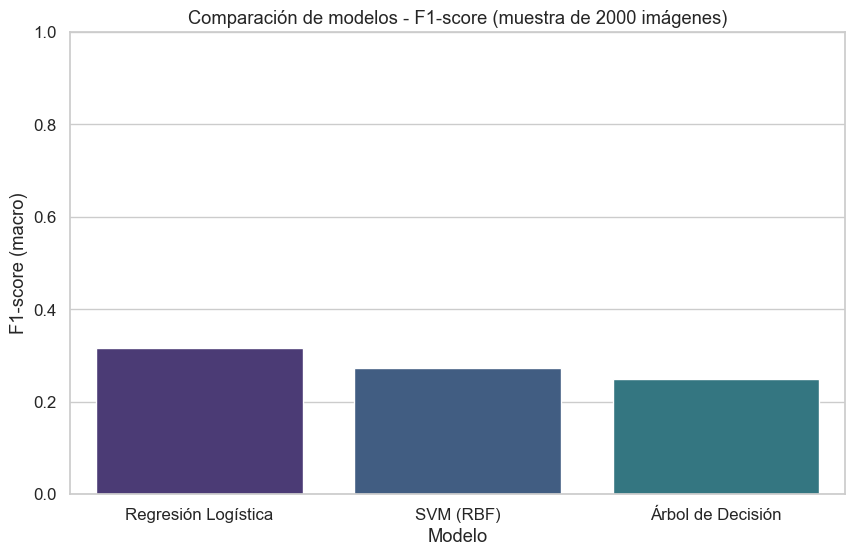

🏆 El modelo con mejor desempeño en la muestra es: **Regresión Logística**


In [27]:
# Mostrar tabla
print("📈 Resultados comparativos (muestra de 2000 imágenes):")
display(resultados.round(4))

# Gráfico comparativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-score', data=resultados, hue='Modelo', dodge=False)
plt.title('Comparación de modelos - F1-score (muestra de 2000 imágenes)')
plt.ylabel('F1-score (macro)')
plt.ylim(0, 1)
plt.legend().set_visible(False)
plt.show()

# Identificar mejor modelo
mejor_modelo = resultados.loc[resultados['F1-score'].idxmax(), 'Modelo']
print(f"🏆 El modelo con mejor desempeño en la muestra es: **{mejor_modelo}**")

## Carga de imágenes

## Entrenamiento con 10000 datos

In [29]:
# Parámetros generales
IMG_SIZE = 64          # Tamaño de las imágenes
N_SAMPLES = 10000      # Número de imágenes para muestra inicial (AJUSTADO A 10000)
RANDOM_SEED = 42       # Semilla para reproducibilidad

# Ruta donde están las imágenes (ajusta si es diferente en tu notebook)
PATH_IMAGES = "images_training_rev1/"

# Configuración visual
import seaborn as sns
import numpy as np
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)
np.random.seed(RANDOM_SEED)

print("Librerías importadas y entorno configurado correctamente.")
print(f"Número de muestras establecido en: {N_SAMPLES}")

Librerías importadas y entorno configurado correctamente.
Número de muestras establecido en: 10000


🔝 Clases seleccionadas (Top 5):
['Class6.2', 'Class1.2', 'Class1.1', 'Class6.1', 'Class1.3']

📂 Imágenes disponibles para las 5 clases: 61578
 Total de imágenes seleccionadas: 8013


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31596\3127267669.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_SAMPLES // 5), random_state=RANDOM_SEED))


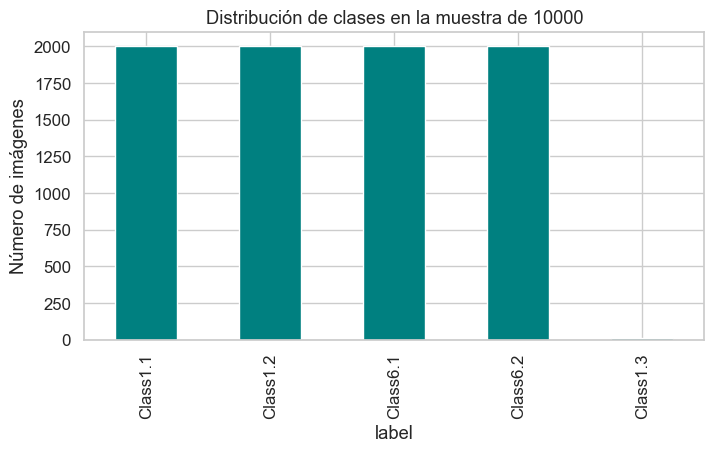

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV
df = pd.read_csv("training_solutions_rev1.csv")

# Crear columna con la clase dominante por fila
df["label"] = df.iloc[:, 1:].idxmax(axis=1)
conteo_clases = df["label"].value_counts()

# Seleccionar las 5 clases con más galaxias
top5_classes = conteo_clases.nlargest(5).index
df_top5 = df[df["label"].isin(top5_classes)]

print(f"🔝 Clases seleccionadas (Top 5):\n{list(top5_classes)}")

# Verificar que existan las imágenes en la carpeta
df_top5["image_path"] = df_top5["GalaxyID"].apply(
    lambda x: os.path.join(PATH_IMAGES, f"{x}.jpg")
)
df_top5 = df_top5[df_top5["image_path"].apply(os.path.exists)]

print(f"\n📂 Imágenes disponibles para las 5 clases: {len(df_top5)}")

# Tomar muestra balanceada de 10000 imágenes
# Se tomarán 2000 imágenes por cada una de las 5 clases más frecuentes.
df_sample = (
    df_top5.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_SAMPLES // 5), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

print(f" Total de imágenes seleccionadas: {len(df_sample)}")

# Mostrar distribución final de la muestra
df_sample["label"].value_counts().plot(
    kind="bar", color="teal", figsize=(8, 4), title="Distribución de clases en la muestra de 10000"
)
plt.ylabel("Número de imágenes")
plt.show()

In [31]:
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ===========================================
# Preprocesamiento de imágenes
# ===========================================

def cargar_imagen(ruta, size=(IMG_SIZE, IMG_SIZE)):
    """Carga una imagen en escala de grises y la devuelve como array normalizado."""
    try:
        img = Image.open(ruta).convert('L')   # Escala de grises
        img = img.resize(size)
        return np.array(img) / 255.0          # Normalizar [0,1]
    except Exception as e:
        print(f" Error al cargar {ruta}: {e}")
        return None

# Cargar todas las imágenes de la muestra
X, y = [], []
print(" Cargando y procesando 10,000 imágenes...")

for _, fila in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Cargando Imágenes"):
    arr = cargar_imagen(fila["image_path"])
    if arr is not None:
        X.append(arr.flatten())  # Convertir imagen a vector 1D
        y.append(fila["label"])

X = np.array(X)
y = np.array(y)

print(f"\n Imágenes cargadas correctamente: {X.shape[0]} muestras, tamaño de vector = {X.shape[1]}")

# Codificar etiquetas (string -> número)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f" Clases codificadas: {list(le.classes_)}")

# ===========================================
# División del conjunto y normalización
# ===========================================

# División en entrenamiento y prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_SEED
)

print(f" Tamaños -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Escalamiento de características
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(" Datos escalados correctamente.")

 Cargando y procesando 10,000 imágenes...


Cargando Imágenes: 100%|█████████████████████████████████████████████████████████| 8013/8013 [00:07<00:00, 1049.62it/s]



 Imágenes cargadas correctamente: 8013 muestras, tamaño de vector = 4096
 Clases codificadas: [np.str_('Class1.1'), np.str_('Class1.2'), np.str_('Class1.3'), np.str_('Class6.1'), np.str_('Class6.2')]
 Tamaños -> Train: 6410, Test: 1603
 Datos escalados correctamente.


 Entrenando modelo: Regresión Logística...


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


convergence after 5817 epochs took 806 seconds
convergence after 6087 epochs took 833 seconds
convergence after 3498 epochs took 483 seconds
convergence after 5583 epochs took 770 seconds


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 60.5min finished


convergence after 5417 epochs took 740 seconds

 Realizando predicciones con Regresión Logística...


Predicción LR: 100%|████████████████████████████████████████████████████████████| 1603/1603 [00:00<00:00, 17233.83it/s]


 Reporte de Clasificación (Regresión Logística):
              precision    recall  f1-score   support

    Class1.1       0.29      0.29      0.29       400
    Class1.2       0.39      0.38      0.39       400
    Class1.3       0.00      0.00      0.00         3
    Class6.1       0.32      0.31      0.31       400
    Class6.2       0.34      0.35      0.34       400

    accuracy                           0.33      1603
   macro avg       0.27      0.27      0.27      1603
weighted avg       0.33      0.33      0.33      1603



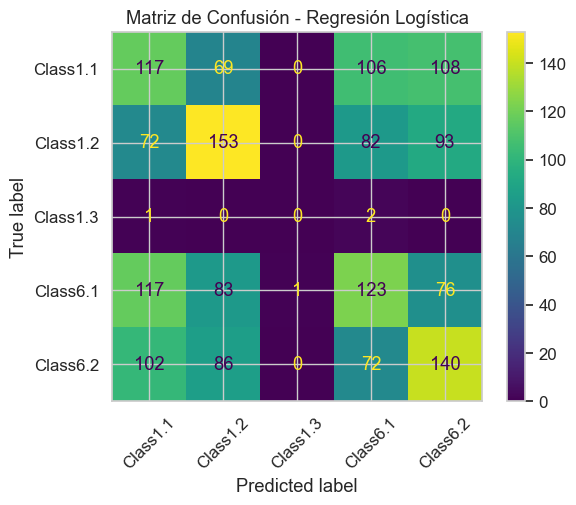

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===========================================
# Regresión Logística
# ===========================================

print(" Entrenando modelo: Regresión Logística...")

# Usamos verbose=1 para que el modelo muestre información durante el entrenamiento
log_reg = LogisticRegression(
    max_iter=10000,  # Aumentamos las iteraciones para asegurar convergencia con más datos
    random_state=RANDOM_SEED,
    multi_class='ovr',
    verbose=1,
    solver='saga' # Saga es un buen solver para datasets grandes
)
log_reg.fit(X_train_s, y_train)

# Predicciones con barra de progreso
print("\n Realizando predicciones con Regresión Logística...")
y_pred_lr = np.array([log_reg.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción LR")])
y_prob_lr = log_reg.predict_proba(X_test_s)

# Reporte de clasificación
print("\n Reporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

In [37]:
from sklearn.preprocessing import label_binarize
import numpy as np

# Asegurar que las dimensiones coincidan con y_prob_lr
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
print("Nueva forma de y_test_bin:", y_test_bin.shape)


Nueva forma de y_test_bin: (1603, 5)


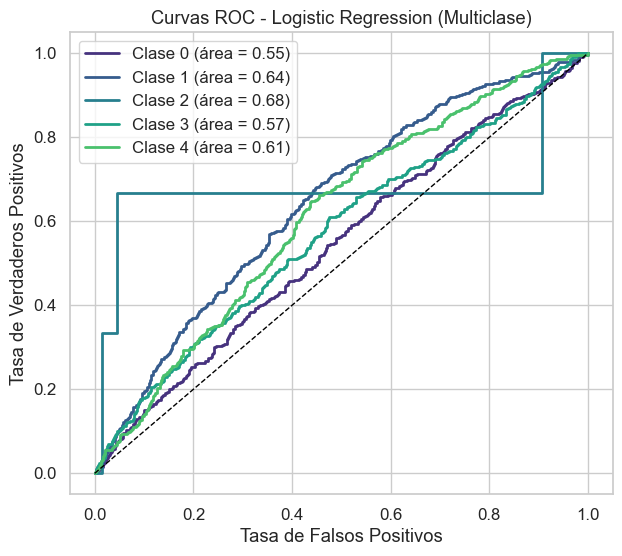

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (área = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Logistic Regression (Multiclase)')
plt.legend()
plt.show()


In [39]:
# Curvas de aprendizaje - Logistic Regression
plot_learning_curve(log_reg, X_train, y_train, title="Curva de Aprendizaje - Logistic Regression")

# Curva de desempeño entrenamiento vs prueba
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


KeyboardInterrupt: 

⚙️ Entrenando modelo: SVM (RBF)... (Este proceso puede tardar)
[LibSVM]
🔍 Realizando predicciones con SVM...


Predicción SVM: 100%|██████████████████████████████████████████████████████████████| 1603/1603 [00:17<00:00, 90.00it/s]



📊 Reporte de Clasificación (SVM):
              precision    recall  f1-score   support

    Class1.1       0.43      0.41      0.42       400
    Class1.2       0.47      0.54      0.50       400
    Class1.3       0.00      0.00      0.00         3
    Class6.1       0.50      0.45      0.47       400
    Class6.2       0.43      0.44      0.44       400

    accuracy                           0.46      1603
   macro avg       0.37      0.37      0.37      1603
weighted avg       0.46      0.46      0.46      1603



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

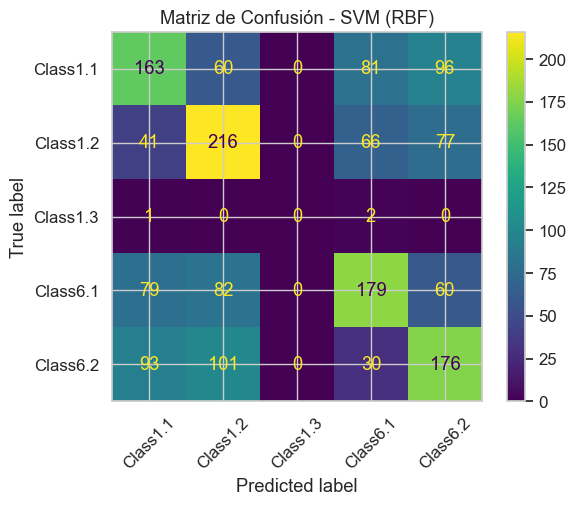

In [8]:
from sklearn.svm import SVC
from tqdm import tqdm
import numpy as np

# ===========================================
# SVM (kernel RBF)
# ===========================================

print("⚙️ Entrenando modelo: SVM (RBF)... (Este proceso puede tardar)")

# Activamos verbose=True para monitorear el entrenamiento de SVM
svm_clf = SVC(
    kernel='rbf',
    probability=True,
    random_state=RANDOM_SEED,
    verbose=True
)
svm_clf.fit(X_train_s, y_train)

# Predicciones con barra de progreso
print("\n🔍 Realizando predicciones con SVM...")
y_pred_svm = np.array([svm_clf.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción SVM")])
y_prob_svm = svm_clf.predict_proba(X_test_s)


print("\n📊 Reporte de Clasificación (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp_svm.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - SVM (RBF)")
plt.show()

In [ ]:
# Curva ROC - SVM
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_prob_svm.ravel(), name="SVM")
plt.title("Curva ROC - SVM")
plt.show()


In [ ]:
# Curvas de aprendizaje - SVM
plot_learning_curve(svm_clf, X_train, y_train, title="Curva de Aprendizaje - SVM")

# Curva de desempeño entrenamiento vs prueba
train_score = svm_clf.score(X_train, y_train)
test_score = svm_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


 Entrenando modelo: Árbol de Decisión...


Entrenamiento Árbol: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:12<00:00, 12.99s/it]



 Realizando predicciones con Árbol de Decisión...


Predicción Árbol: 100%|█████████████████████████████████████████████████████████| 1603/1603 [00:00<00:00, 16402.95it/s]



 Reporte de Clasificación (Árbol de Decisión):
              precision    recall  f1-score   support

    Class1.1       0.40      0.41      0.41       400
    Class1.2       0.38      0.38      0.38       400
    Class1.3       0.00      0.00      0.00         3
    Class6.1       0.37      0.36      0.36       400
    Class6.2       0.29      0.29      0.29       400

    accuracy                           0.36      1603
   macro avg       0.29      0.29      0.29      1603
weighted avg       0.36      0.36      0.36      1603



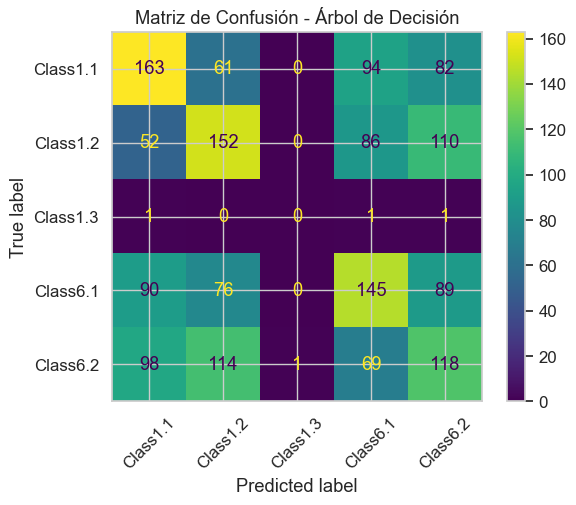

In [9]:
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm
import numpy as np

# ===========================================
# Árbol de Decisión
# ===========================================

print(" Entrenando modelo: Árbol de Decisión...")

tree_clf = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Envolvemos el fit con tqdm, aunque sea rápido
with tqdm(total=1, desc="Entrenamiento Árbol") as pbar:
    tree_clf.fit(X_train_s, y_train)
    pbar.update(1)

# Predicciones con barra de progreso
print("\n Realizando predicciones con Árbol de Decisión...")
y_pred_tree = np.array([tree_clf.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción Árbol")])
y_prob_tree = tree_clf.predict_proba(X_test_s)

print("\n Reporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=le.classes_)
disp_tree.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

In [ ]:
# Curva ROC - Decision Tree
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_prob_tree.ravel(), name="Decision Tree")
plt.title("Curva ROC - Decision Tree")
plt.show()


In [ ]:
# Curvas de aprendizaje - Decision Tree
plot_learning_curve(tree_clf, X_train, y_train, title="Curva de Aprendizaje - Decision Tree")

# Curva de desempeño entrenamiento vs prueba
train_score = tree_clf.score(X_train, y_train)
test_score = tree_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


 Resultados comparativos (muestra de 10000 imágenes):


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.3325,0.2665,0.2665,0.2664
1,SVM (RBF),0.4579,0.3667,0.3670,0.3660
2,Árbol de Decisión,0.3606,0.2885,0.2890,0.2888


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15464\388303731.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


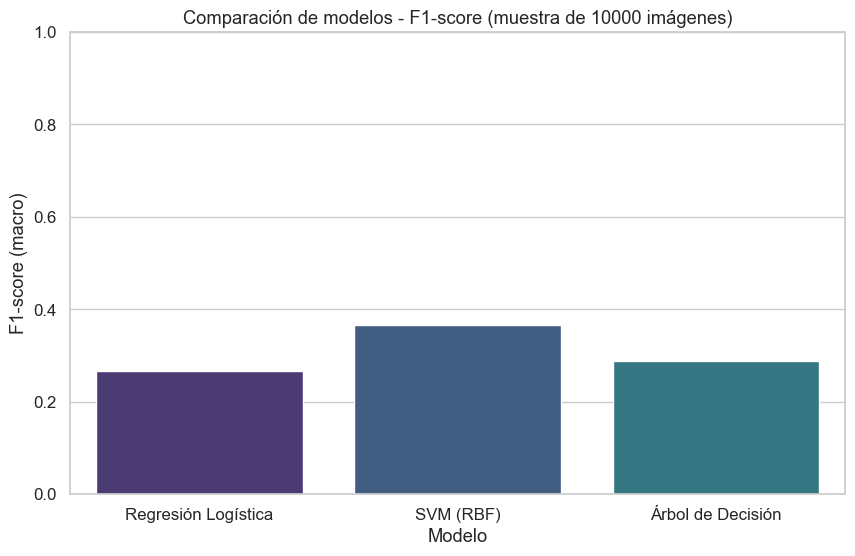

 El modelo con mejor desempeño en la muestra es: **SVM (RBF)** con un F1-score de 0.3660


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular métricas para cada modelo
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM (RBF)', 'Árbol de Decisión'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
        precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
        precision_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
        recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
        recall_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
        f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
        f1_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ]
})

# Mostrar tabla de resultados
print(" Resultados comparativos (muestra de 10000 imágenes):")
display(resultados.round(4))

# Gráfico comparativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-score', data=resultados, hue='Modelo', dodge=False)
plt.title('Comparación de modelos - F1-score (muestra de 10000 imágenes)')
plt.ylabel('F1-score (macro)')
plt.ylim(0, 1)
plt.legend().set_visible(False)
plt.show()

# Identificar el mejor modelo basado en F1-score
mejor_modelo = resultados.loc[resultados['F1-score'].idxmax()]
print(f" El modelo con mejor desempeño en la muestra es: **{mejor_modelo['Modelo']}** con un F1-score de {mejor_modelo['F1-score']:.4f}")

# Estudio con la totalidad de los datos

In [ ]:
# Parámetros generales
IMG_SIZE = 64          # Tamaño de las imágenes
N_SAMPLES = 61578      # Número de imágenes para muestra inicial (AJUSTADO A 10000)
RANDOM_SEED = 42       # Semilla para reproducibilidad

# Ruta donde están las imágenes (ajusta si es diferente en tu notebook)
PATH_IMAGES = "images_training_rev1/"

# Configuración visual
import seaborn as sns
import numpy as np
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)
np.random.seed(RANDOM_SEED)

print("Librerías importadas y entorno configurado correctamente.")
print(f"Número de muestras establecido en: {N_SAMPLES}")

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo CSV
df = pd.read_csv("training_solutions_rev1.csv")

# Crear columna con la clase dominante por fila
df["label"] = df.iloc[:, 1:].idxmax(axis=1)
conteo_clases = df["label"].value_counts()

# Seleccionar las 5 clases con más galaxias
top5_classes = conteo_clases.nlargest(5).index
df_top5 = df[df["label"].isin(top5_classes)]

print(f"🔝 Clases seleccionadas (Top 5):\n{list(top5_classes)}")

# Verificar que existan las imágenes en la carpeta
df_top5["image_path"] = df_top5["GalaxyID"].apply(
    lambda x: os.path.join(PATH_IMAGES, f"{x}.jpg")
)
df_top5 = df_top5[df_top5["image_path"].apply(os.path.exists)]

print(f"\n📂 Imágenes disponibles para las 5 clases: {len(df_top5)}")

# Tomar muestra balanceada de 10000 imágenes
# Se tomarán 2000 imágenes por cada una de las 5 clases más frecuentes.
df_sample = (
    df_top5.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_SAMPLES // 5), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

print(f" Total de imágenes seleccionadas: {len(df_sample)}")

# Mostrar distribución final de la muestra
df_sample["label"].value_counts().plot(
    kind="bar", color="teal", figsize=(8, 4), title="Distribución de clases en la muestra de 10000"
)
plt.ylabel("Número de imágenes")
plt.show()

In [ ]:
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ===========================================
# Preprocesamiento de imágenes
# ===========================================

def cargar_imagen(ruta, size=(IMG_SIZE, IMG_SIZE)):
    """Carga una imagen en escala de grises y la devuelve como array normalizado."""
    try:
        img = Image.open(ruta).convert('L')   # Escala de grises
        img = img.resize(size)
        return np.array(img) / 255.0          # Normalizar [0,1]
    except Exception as e:
        print(f" Error al cargar {ruta}: {e}")
        return None

# Cargar todas las imágenes de la muestra
X, y = [], []
print(" Cargando y procesando 10,000 imágenes...")

for _, fila in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Cargando Imágenes"):
    arr = cargar_imagen(fila["image_path"])
    if arr is not None:
        X.append(arr.flatten())  # Convertir imagen a vector 1D
        y.append(fila["label"])

X = np.array(X)
y = np.array(y)

print(f"\n Imágenes cargadas correctamente: {X.shape[0]} muestras, tamaño de vector = {X.shape[1]}")

# Codificar etiquetas (string -> número)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f" Clases codificadas: {list(le.classes_)}")

# ===========================================
# División del conjunto y normalización
# ===========================================

# División en entrenamiento y prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_SEED
)

print(f" Tamaños -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Escalamiento de características
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(" Datos escalados correctamente.")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===========================================
# Regresión Logística
# ===========================================

print(" Entrenando modelo: Regresión Logística...")

# Usamos verbose=1 para que el modelo muestre información durante el entrenamiento
log_reg = LogisticRegression(
    max_iter=10000,  # Aumentamos las iteraciones para asegurar convergencia con más datos
    random_state=RANDOM_SEED,
    multi_class='ovr',
    verbose=1,
    solver='saga' # Saga es un buen solver para datasets grandes
)
log_reg.fit(X_train_s, y_train)

# Predicciones con barra de progreso
print("\n Realizando predicciones con Regresión Logística...")
y_pred_lr = np.array([log_reg.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción LR")])
y_prob_lr = log_reg.predict_proba(X_test_s)

# Reporte de clasificación
print("\n Reporte de Clasificación (Regresión Logística):")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
disp_lr.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

In [ ]:
# Curva ROC - Logistic Regression
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_prob_lr.ravel(), name="Logistic Regression")
plt.title("Curva ROC - Logistic Regression")
plt.show()


In [ ]:
# Curvas de aprendizaje - Logistic Regression
plot_learning_curve(log_reg, X_train, y_train, title="Curva de Aprendizaje - Logistic Regression")

# Curva de desempeño entrenamiento vs prueba
train_score = log_reg.score(X_train, y_train)
test_score = log_reg.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


In [ ]:
from sklearn.svm import SVC
from tqdm import tqdm
import numpy as np

# ===========================================
# SVM (kernel RBF)
# ===========================================

print("⚙️ Entrenando modelo: SVM (RBF)... (Este proceso puede tardar)")

# Activamos verbose=True para monitorear el entrenamiento de SVM
svm_clf = SVC(
    kernel='rbf',
    probability=True,
    random_state=RANDOM_SEED,
    verbose=True
)
svm_clf.fit(X_train_s, y_train)

# Predicciones con barra de progreso
print("\n🔍 Realizando predicciones con SVM...")
y_pred_svm = np.array([svm_clf.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción SVM")])
y_prob_svm = svm_clf.predict_proba(X_test_s)


print("\n📊 Reporte de Clasificación (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp_svm.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - SVM (RBF)")
plt.show()

In [ ]:
# Curva ROC - SVM
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_prob_svm.ravel(), name="SVM")
plt.title("Curva ROC - SVM")
plt.show()


In [ ]:
# Curvas de aprendizaje - SVM
plot_learning_curve(svm_clf, X_train, y_train, title="Curva de Aprendizaje - SVM")

# Curva de desempeño entrenamiento vs prueba
train_score = svm_clf.score(X_train, y_train)
test_score = svm_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm
import numpy as np

# ===========================================
# Árbol de Decisión
# ===========================================

print(" Entrenando modelo: Árbol de Decisión...")

tree_clf = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Envolvemos el fit con tqdm, aunque sea rápido
with tqdm(total=1, desc="Entrenamiento Árbol") as pbar:
    tree_clf.fit(X_train_s, y_train)
    pbar.update(1)

# Predicciones con barra de progreso
print("\n Realizando predicciones con Árbol de Decisión...")
y_pred_tree = np.array([tree_clf.predict(X_test_s[i:i+1]) for i in tqdm(range(len(X_test_s)), desc="Predicción Árbol")])
y_prob_tree = tree_clf.predict_proba(X_test_s)

print("\n Reporte de Clasificación (Árbol de Decisión):")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=le.classes_)
disp_tree.plot(cmap='viridis', xticks_rotation=45)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

In [ ]:
# Curva ROC - Decision Tree
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_bin.ravel(), y_prob_tree.ravel(), name="Decision Tree")
plt.title("Curva ROC - Decision Tree")
plt.show()


In [ ]:
# Curvas de aprendizaje - Decision Tree
plot_learning_curve(tree_clf, X_train, y_train, title="Curva de Aprendizaje - Decision Tree")

# Curva de desempeño entrenamiento vs prueba
train_score = tree_clf.score(X_train, y_train)
test_score = tree_clf.score(X_test, y_test)
print(f"Precisión Entrenamiento: {train_score:.3f}")
print(f"Precisión Validación/Test: {test_score:.3f}")


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular métricas para cada modelo
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM (RBF)', 'Árbol de Decisión'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='macro', zero_division=0),
        precision_score(y_test, y_pred_svm, average='macro', zero_division=0),
        precision_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='macro', zero_division=0),
        recall_score(y_test, y_pred_svm, average='macro', zero_division=0),
        recall_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr, average='macro', zero_division=0),
        f1_score(y_test, y_pred_svm, average='macro', zero_division=0),
        f1_score(y_test, y_pred_tree, average='macro', zero_division=0)
    ]
})

# Mostrar tabla de resultados
print(" Resultados comparativos (muestra de 10000 imágenes):")
display(resultados.round(4))

# Gráfico comparativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-score', data=resultados, hue='Modelo', dodge=False)
plt.title('Comparación de modelos - F1-score (muestra de 10000 imágenes)')
plt.ylabel('F1-score (macro)')
plt.ylim(0, 1)
plt.legend().set_visible(False)
plt.show()

# Identificar el mejor modelo basado en F1-score
mejor_modelo = resultados.loc[resultados['F1-score'].idxmax()]
print(f" El modelo con mejor desempeño en la muestra es: **{mejor_modelo['Modelo']}** con un F1-score de {mejor_modelo['F1-score']:.4f}")